# Bonus

🎯 84 feature’dan oluşan tam `ML_Houses_dataset.csv` dataset’iyle [buradan ulaşarak](https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_dataset.csv) serbestçe çalışabilirsiniz!

- Feature’ları inceleyin
- Uygun şekilde preprocess edin ve encode edin
- Feature engineering için beyin fırtınası yapın
- Bunları modelinize ekleyin
- Feature selection uygulayın

👇 Dosyayı yerel olarak `data` klasörüne kaydedin ve buradan içe aktarın.

In [3]:
import pandas as pd
df = pd.read_csv('/Users/emre/Downloads/ML_Houses_dataset.csv')
df.head

<bound method NDFrame.head of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1755  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1756   118          20       RL         74.0     8536   Pave   NaN      Reg   
1757   253          60       RL         65.0     8366   Pave   NaN      IR1   
1758   199          75       RM         92.0     5520   Pave   NaN      Reg   
1759   403          30       RL         60.0    10200   Pave   NaN      Reg   

     LandContour Util

In [4]:
df.shape

(1760, 85)

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1760 entries, 0 to 1759
Data columns (total 85 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1760 non-null   int64  
 1   MSSubClass     1760 non-null   int64  
 2   MSZoning       1760 non-null   object 
 3   LotFrontage    1451 non-null   float64
 4   LotArea        1760 non-null   int64  
 5   Street         1760 non-null   object 
 6   Alley          112 non-null    object 
 7   LotShape       1760 non-null   object 
 8   LandContour    1760 non-null   object 
 9   Utilities      1760 non-null   object 
 10  LotConfig      1760 non-null   object 
 11  LandSlope      1760 non-null   object 
 12  Neighborhood   1760 non-null   object 
 13  Condition1     1760 non-null   object 
 14  Condition2     1760 non-null   object 
 15  BldgType       1760 non-null   object 
 16  HouseStyle     1760 non-null   object 
 17  OverallQual    1760 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,Pesos,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1760.000000,1760.000000,1451.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1751.000000,1.747000e+03,...,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000
mean,727.141477,57.210227,70.461751,10536.740341,6.107955,5.572159,1971.317614,1984.630682,104.973729,3.631104e+06,...,94.631250,46.959659,22.942614,3.203977,14.931250,2.888636,44.123864,6.336932,2007.815341,182289.685227
std,422.491995,42.231005,24.782149,9449.032214,1.399157,1.114491,30.110328,20.643127,185.951218,1.628917e+06,...,124.720977,66.583959,62.179348,28.329758,55.620643,40.699848,495.619906,2.700009,1.334159,82143.250734
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,6.980000e+05,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,358.000000,20.000000,59.500000,7587.250000,5.000000,5.000000,1954.000000,1966.750000,0.000000,2.598000e+06,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129900.000000
50%,726.500000,50.000000,70.000000,9525.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,3.260000e+06,...,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163500.000000
75%,1095.250000,70.000000,80.000000,11665.500000,7.000000,6.000000,2000.000000,2004.000000,165.500000,4.280000e+06,...,168.000000,69.250000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214925.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,1.510000e+07,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
#Boolean kontrolü; yani duplicate
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate rows: 300


In [7]:
#Object olup float olması gereken sütunları düzelt;

for col in df.columns:
    if df[col].dtype == "object":
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

In [9]:
#Null değerleri görelim
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

WallMat         1455
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
Pesos             10
RoofSurface        9
MasVnrArea         8
Electrical         1
dtype: int64

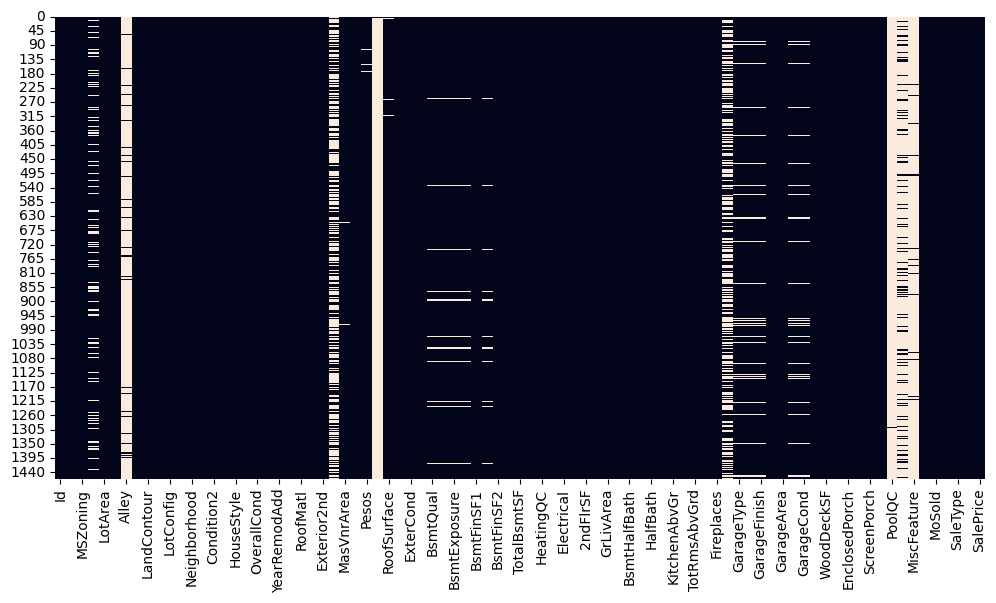

In [8]:
#null değer kontrolü
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [10]:
# %30 un üzerinde null değer olan sütunları sil, GEREKSİZ
cols_to_drop = [
    "WallMat",
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu"
]

df = df.drop(columns=cols_to_drop)

In [11]:
#Feature Tiplerini ayıralım
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 40
Categorical: 38


In [12]:
#Sayısal değerlerde eksik olanları median ile dolduralım
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")

df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [13]:
#kategorikleri ayıralım
cat_imputer = SimpleImputer(strategy="most_frequent")

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [14]:
#tekrar null kontrol
df.isnull().sum().sum()

np.int64(0)

In [15]:
#Encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [16]:
#Scale edelim
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df.select_dtypes(include=["int64","float64"]).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

In [17]:
#Feature / Target ayrımı yapalım
X = df.drop(columns="SalePrice")
y = df["SalePrice"]

In [18]:
#Train / Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
#Linear Model Oluşturalım (basic)

from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [20]:
#kurduğumuz modelin genel performansını inceleyelim
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV scores:", scores)
print("Mean CV score:", scores.mean())

CV scores: [0.94038098 0.88359983 0.95352946 0.94590154 0.92225029]
Mean CV score: 0.9291324203495817


In [21]:
#Şimdi modeli eğitelim;
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
#Test performansına bakalım
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

print("Test R2:", r2_score(y_test, y_pred))

Test R2: 0.9648133843827577


In [23]:
#Learning Curve / grafiği çizelim ve bakalım. Yorumlayalım
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

In [24]:
#Ortalama Skor
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

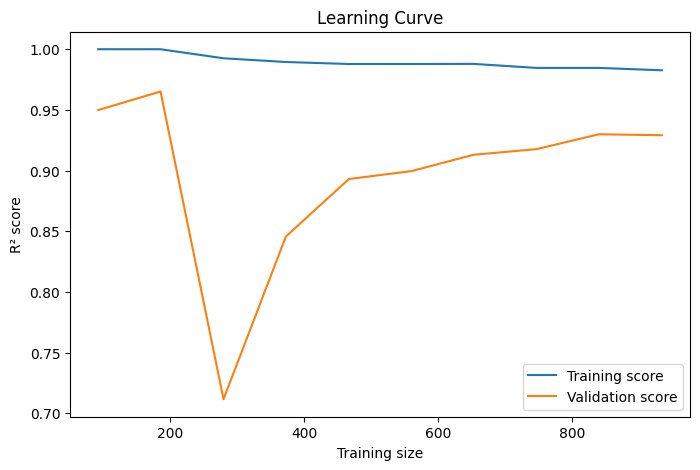

In [26]:
#Grafiğe bakalım
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Validation score")

plt.xlabel("Training size")
plt.ylabel("R² score")
plt.title("Learning Curve")

plt.legend()
plt.show()

#Learning Curve , çok fazla veri olduğu için modeli ezberledi. Bu yüzden 1.00 a çok yakın. Bu iyi bir şey dğeil. bazı Sütunları kaldıralım, feature engineering yapalım

In [27]:
#sale_price bir bir regresyon hedefi. Bunu label encode etmek doğru değil. Sayısal bırakmalıyız
import numpy as np

y = np.log1p(df["SalePrice"])
X = df.drop(columns="SalePrice")

/Users/emre/.pyenv/versions/workintech/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [30]:
# target ayır
y = df["SalePrice"]

# feature set
X = df.drop(columns="SalePrice")

# scaling
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# log transform
import numpy as np
y = np.log1p(y)

/Users/emre/.pyenv/versions/workintech/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [31]:
import numpy as np
from sklearn.preprocessing import RobustScaler

# target ayır
y = df["SalePrice"]

# log transform önce yapılır
y = np.log1p(y)

# feature set
X = df.drop(columns="SalePrice")

# sadece sayısal kolonları seç
num_cols = X.select_dtypes(include=["int64","float64"]).columns

# scaler
scaler = RobustScaler()

# sadece feature'ları scale et
X[num_cols] = scaler.fit_transform(X[num_cols])

In [32]:
df["SalePrice"].min()

np.float64(-1.8387037612340333)

In [33]:
#SalePrice da eksi değerler olduğu için modeli tekrardan kuruyorum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

In [35]:
df = pd.read_csv('/Users/emre/Downloads/ML_Houses_dataset.csv')
df_raw = df.copy()

In [36]:
print(df.shape)
print(df["SalePrice"].min())
df.head()

(1760, 85)
34900


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [37]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.head(20)

WallMat         1755
PoolQC          1751
MiscFeature     1694
Alley           1648
Fence           1418
MasVnrType      1062
FireplaceQu      827
LotFrontage      309
GarageType        93
GarageYrBlt       93
GarageFinish      93
GarageQual        93
GarageCond        93
BsmtFinType2      45
BsmtExposure      44
BsmtCond          43
BsmtFinType1      43
BsmtQual          43
Pesos             13
RoofSurface       10
dtype: int64

In [38]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 300


In [39]:
missing_ratio = df.isnull().mean().sort_values(ascending=False)
cols_to_drop = missing_ratio[missing_ratio > 0.4].index.tolist()

print("Drop edilecek sütunlar:", cols_to_drop)

df = df.drop(columns=cols_to_drop)

Drop edilecek sütunlar: ['WallMat', 'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']


In [40]:
#Object olup numeric olması gerekenler
for col in df.select_dtypes(include="object").columns:
    converted = pd.to_numeric(df[col], errors="coerce")
    
    # Eğer dönüşüm sonrası anlamlı sayıda değer numeric olmuşsa, sütunu numeric kabul et
    if converted.notna().sum() > 0.8 * len(df):
        df[col] = converted

In [41]:
 df.dtypes.value_counts()

object     38
int64      35
float64     5
Name: count, dtype: int64

In [42]:
#Target/Feat ayrımı
y = pd.to_numeric(df["SalePrice"], errors="coerce")
df = df.dropna(subset=["SalePrice"])

y = df["SalePrice"]
X = df.drop(columns="SalePrice")

In [43]:
y = np.log1p(y)

In [44]:
#Feature Engineering yapalım
X["HouseAge"] = X["YrSold"] - X["YearBuilt"]
X["RemodAge"] = X["YrSold"] - X["YearRemodAdd"]

X["TotalSF"] = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"]

X["TotalBath"] = (
    X["FullBath"] + 0.5 * X["HalfBath"] +
    X["BsmtFullBath"] + 0.5 * X["BsmtHalfBath"]
)

X["TotalPorchSF"] = (
    X["OpenPorchSF"] +
    X["EnclosedPorch"] +
    X["3SsnPorch"] +
    X["ScreenPorch"]
)

X["HasPool"] = (X["PoolArea"] > 0).astype(int)
X["HasGarage"] = (X["GarageArea"] > 0).astype(int)
X["HasFireplace"] = (X["Fireplaces"] > 0).astype(int)
X["HasBasement"] = (X["TotalBsmtSF"] > 0).astype(int)

In [45]:
#numeric ve kategorik sütunları ayıralım
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 48
Categorical: 38


In [46]:
#Eksik Değerleri Doldularım
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X[num_cols] = num_imputer.fit_transform(X[num_cols])
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

In [47]:
#Kategorikleri Encode edelim
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [48]:
#nUMERİC FEATURESLARI SCALE EDELİM
num_cols_final = X.select_dtypes(include=["int64", "float64"]).columns

scaler = RobustScaler()
X[num_cols_final] = scaler.fit_transform(X[num_cols_final])

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
#Düz LinearRegression yerine Ridge daha mantıklı, çünkü çok sayıda sütunda regularization iş görür.
model = Ridge(alpha=10.0)
model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [51]:
#Cross Validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")

print("CV scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

CV scores: [0.94889018 0.93528117 0.95094963 0.93695049 0.94107022]
Mean CV R2: 0.942628339497681


In [52]:
#test performansı
y_pred = model.predict(X_test)

print("Test R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Test R2: 0.943049207222381
RMSE: 0.09940915746332174


In [53]:
#lEARNİNG CURVE
train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

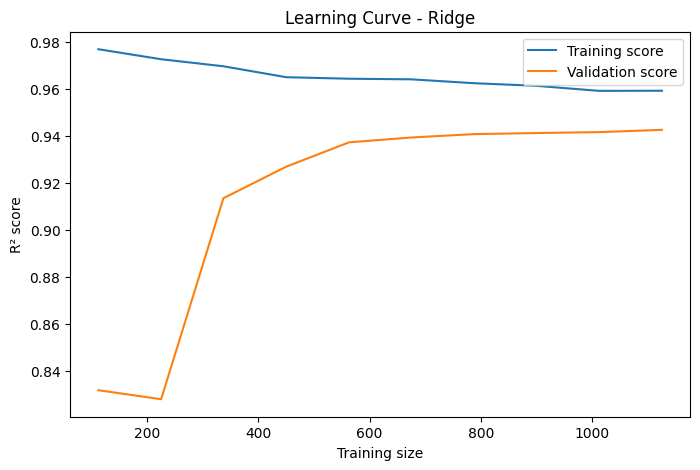

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Validation score")

plt.xlabel("Training size")
plt.ylabel("R² score")
plt.title("Learning Curve - Ridge")
plt.legend()
plt.show()

ℹ️ Dataset’in açıklamasına mutlaka [buradan](https://drive.google.com/file/d/1qLxeQXufW_-KHOckpUweLPhitzjnP7H3/view?usp=sharing) referans verin.